In [34]:
#START - GETTING STARTED WITH EXPLORATION

# --- Core imports ---
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Always show plots inline
%matplotlib inline

# --- Path sanity check ---
print("Notebook running from:", Path.cwd())

# Define project paths
ROOT = Path("..").resolve()   # one level up from 'notebooks' → 'BBO'
DATA = ROOT / "data"

print("ROOT:", ROOT)
print("DATA:", DATA)

# List subfolders/files inside data
print("Contents of DATA:")
for p in sorted(DATA.iterdir()):
    print("   ", p.name)

Notebook running from: C:\Users\elena\Documents\BBO\notebooks
ROOT: C:\Users\elena\Documents\BBO
DATA: C:\Users\elena\Documents\BBO\data
Contents of DATA:
    F1
    F2
    F3
    F4
    F5
    F6
    F7
    F8
    function_summary.csv


In [35]:
#DATA LOADING SECTION
# --- Select which function to inspect ---
FN = "F8"   # change to F2..F8 as needed
print(f"Loading data for {FN}")

# --- Read function description ---
summary_path = DATA / "function_summary.csv"
func_info = pd.read_csv(summary_path)

if "Function" in func_info.columns and "Description" in func_info.columns:
    desc_row = func_info.loc[func_info["Function"] == FN, "Description"]
    if not desc_row.empty:
        print(f"\n{FN} description:\n{desc_row.values[0]}")
    else:
        print(f"No description found for {FN} in function_summary.csv.")
else:
    print("⚠️ function_summary.csv missing expected columns.")

# --- Load inputs/outputs ---
X_path = DATA / FN / "initial_inputs.npy"
y_path = DATA / FN / "initial_outputs.npy"

X = np.load(X_path)
y = np.load(y_path)

# --- Build DataFrame for exploration ---
cols = [f"x{i+1}" for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=cols)
df["y"] = y

# --- Show quick look ---
display(df.head())
display(df.describe())

# --- Summary dictionary ---
summary = {
    "rows": len(df),
    "dims": X.shape[1],
    "bounds": {c: (float(df[c].min()), float(df[c].max())) for c in cols},
    "y_min": float(df["y"].min()),
    "y_max": float(df["y"].max()),
}
print("\nSummary of loaded data:")
summary


Loading data for F8

F8 description:
You’re optimising an eight-dimensional black-box function, where each of the eight input parameters affects the output, but the internal mechanics are unknown. 
Your objective is to find the parameter combination that maximises the function’s output, such as performance, efficiency or validation accuracy. Because the function is high-dimensional and likely complex, global optimisation is hard, so identifying strong local maxima is often a practical strategy.
For example, imagine you’re tuning an ML model with eight hyperparameters: learning rate, batch size, number of layers, dropout rate, regularisation strength, activation function (numerically encoded), optimiser type (encoded) and initial weight range. Each input set returns a single validation accuracy score between 0 and 1. Your goal is to maximise this score.


,x1,x2,x3,x4,x5,x6,x7,x8,y
0,0.604994,0.292215,0.908453,0.355506,0.201669,0.575338,0.310311,0.734281,7.398721
1,0.178007,0.566223,0.994862,0.210325,0.320153,0.707909,0.635384,0.107132,7.005227
2,0.009077,0.811626,0.520520,0.075687,0.265112,0.091652,0.592415,0.367320,8.459482
3,0.506028,0.653730,0.363411,0.177981,0.093728,0.197425,0.755827,0.292472,8.284008
4,0.359909,0.249076,0.495997,0.709215,0.114987,0.289207,0.557295,0.593882,8.606117


,x1,x2,x3,x4,x5,x6,x7,x8,y
count,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000
mean,0.533765,0.472829,0.515580,0.432145,0.469708,0.461098,0.577264,0.506556,7.839251
std,0.306815,0.305841,0.278898,0.258418,0.277883,0.273957,0.254969,0.277810,0.959268
min,0.009077,0.003419,0.022929,0.009043,0.009649,0.022113,0.035909,0.041956,5.592193
25%,0.338954,0.218851,0.314142,0.180148,0.240298,0.245548,0.435010,0.295518,7.299872
50%,0.532721,0.523642,0.495997,0.487566,0.414579,0.410105,0.592415,0.524885,7.923759
75%,0.791888,0.699506,0.729546,0.662216,0.719701,0.706650,0.765670,0.728611,8.541748
max,0.985945,0.973980,0.998885,0.902986,0.986902,0.990244,0.992914,0.988755,9.598482



Summary of loaded data:


{'rows': 41,
 'dims': 8,
 'bounds': {'x1': (0.009076976680729043, 0.9859453896331098),
  'x2': (0.0034194994840646142, 0.9739797874919709),
  'x3': (0.02292867798954412, 0.9988854968558359),
  'x4': (0.009043485399991336, 0.9029857747482919),
  'x5': (0.009648877991745852, 0.986901999632929),
  'x6': (0.022113406876058894, 0.9902438143772585),
  'x7': (0.03590887616954386, 0.992914494924961),
  'x8': (0.04195606945702324, 0.9887551042522277)},
 'y_min': 5.5921933895401965,
 'y_max': 9.598482002566342}

In [36]:
# --- save summary info + notes + timestamp to spreadsheet ---
sdf = pd.read_csv(DATA / "function_summary.csv")
note = f"Exploration: {summary['dims']}D, {summary['rows']} pts. y∈[{summary['y_min']:.6g},{summary['y_max']:.3g}]"
now  = pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")

sdf.loc[sdf["Function"] == FN,
        ["Rows","Dims","Bounds","y_min","y_max","Best_y_so_far","Notes","Last_updated"]] = [
    summary["rows"], summary["dims"], str(summary["bounds"]),
    summary["y_min"], summary["y_max"], summary["y_max"], note, now
]

sdf.to_csv(DATA / "function_summary.csv", index=False)


F8 has 8 input dimensions


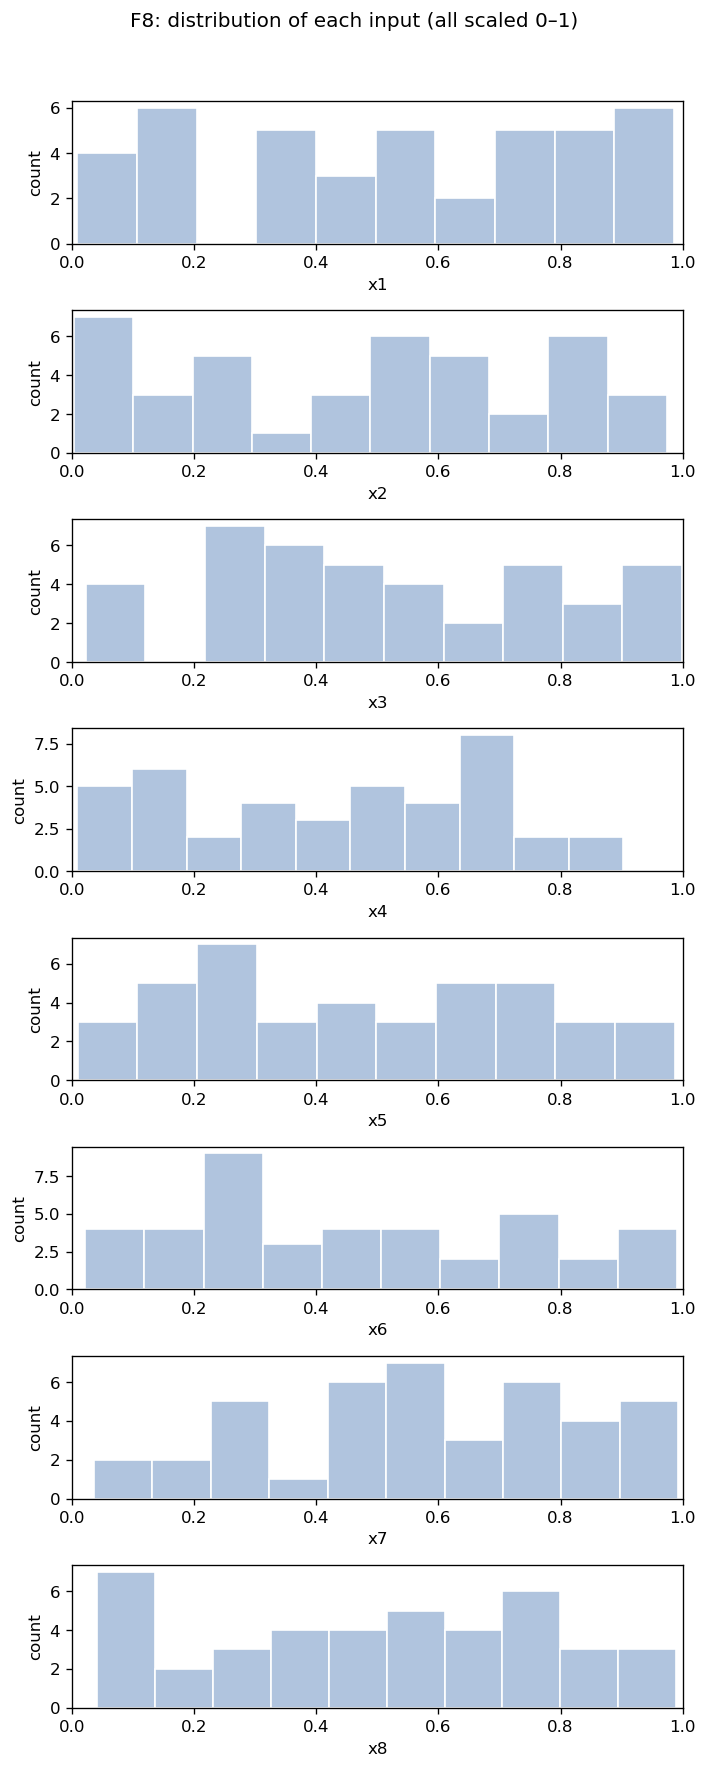

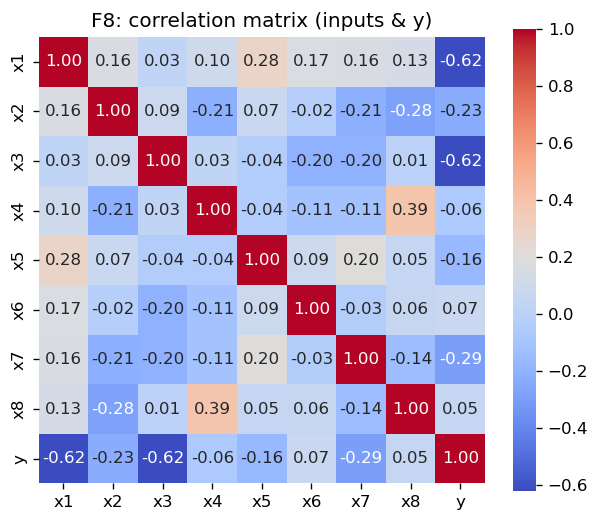

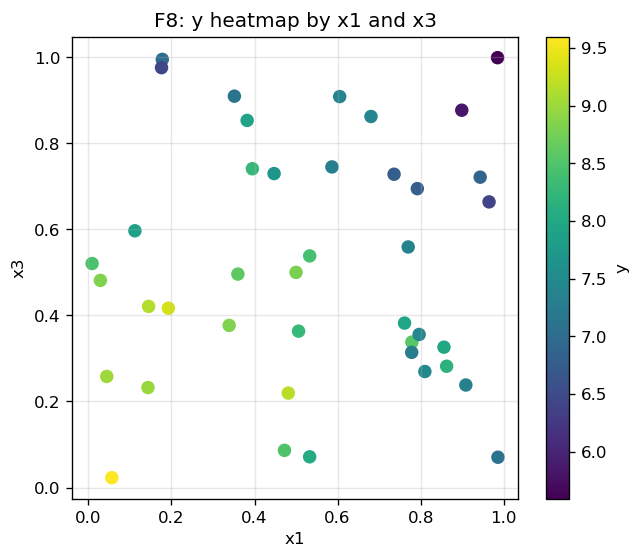

In [37]:
#INITIAL PLOTS TO VISUALISE THE DATA

# --- Quick visual exploration of inputs and outputs ---
import seaborn as sns

xs = [c for c in df.columns if c.startswith("x")]
d = len(xs)

print(f"{FN} has {d} input dimensions")

if d == 1:
    plt.scatter(df[xs[0]], df["y"], s=30, color="steelblue")
    plt.xlabel(xs[0]); plt.ylabel("y")
    plt.title(f"{FN}: y vs {xs[0]}")
    plt.grid(True, alpha=0.3)
    plt.show()

elif d == 2:
    sc = plt.scatter(df[xs[0]], df[xs[1]], c=df["y"], cmap="viridis", s=40)
    plt.xlabel(xs[0]); plt.ylabel(xs[1])
    plt.title(f"{FN}: inputs coloured by y (higher = better)")
    plt.colorbar(sc, label="y")
    plt.grid(True, alpha=0.3)
    plt.show()

else:
    # --- 1D distributions per input ---
    fig, axs = plt.subplots(d, 1, figsize=(6, 1.8*d), dpi=120)
    for i, c in enumerate(xs):
        axs[i].hist(df[c], bins=10, color="lightsteelblue", edgecolor="white")
        axs[i].set_xlabel(c); axs[i].set_ylabel("count")
        axs[i].set_xlim(0,1)
    fig.suptitle(f"{FN}: distribution of each input (all scaled 0–1)", y=1.02)
    plt.tight_layout()
    plt.show()

    # --- correlation matrix (inputs + y) ---
    corr = df.corr(numeric_only=True)
    plt.figure(figsize=(6,5), dpi=120)
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
    plt.title(f"{FN}: correlation matrix (inputs & y)")
    plt.show()

    # --- top 2D coloured scatter using most correlated vars with y ---
    corr_y = corr["y"].abs().sort_values(ascending=False)
    top2 = corr_y.index[1:3]  # skip 'y' itself
    if len(top2) == 2:
        plt.figure(figsize=(6,5), dpi=120)
        sc = plt.scatter(df[top2[0]], df[top2[1]], c=df["y"], cmap="viridis", s=50)
        plt.xlabel(top2[0]); plt.ylabel(top2[1])
        plt.title(f"{FN}: y heatmap by {top2[0]} and {top2[1]}")
        plt.colorbar(sc, label="y")
        plt.grid(True, alpha=0.3)
        plt.show()


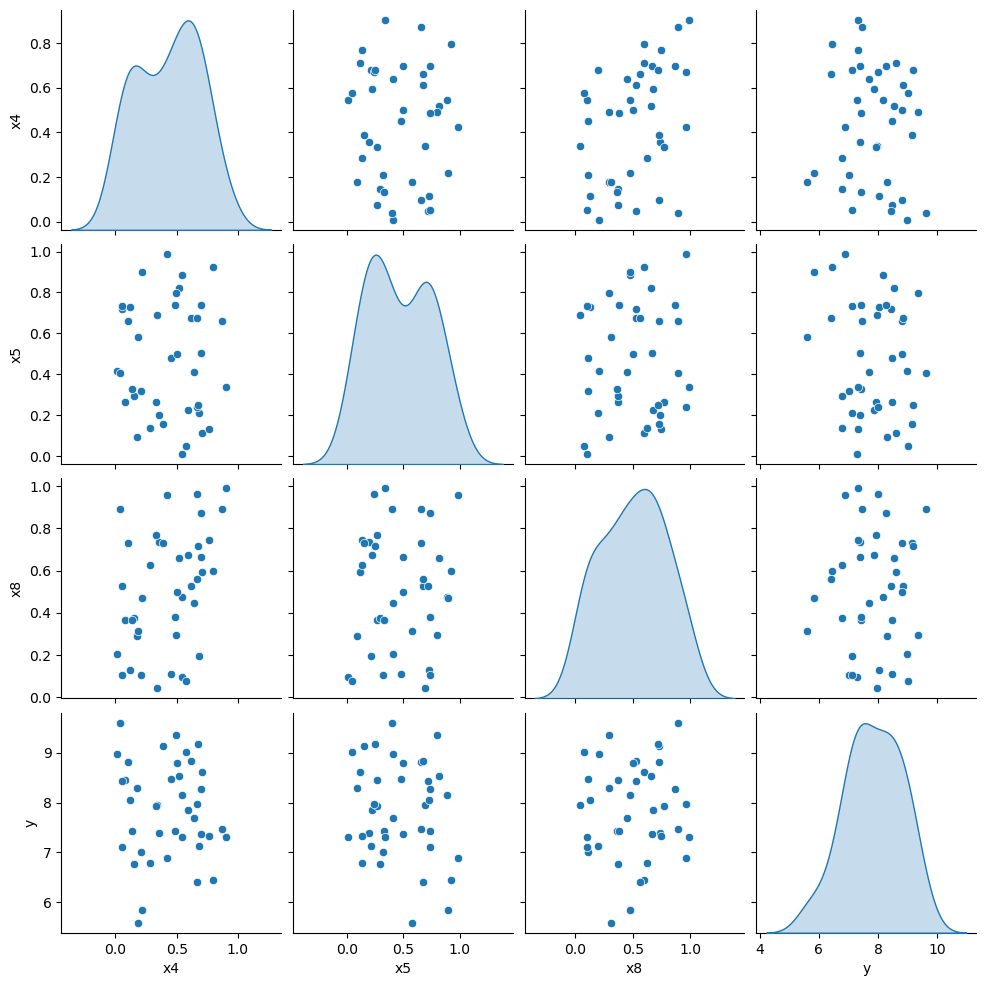

In [38]:
# --- pairwise relationships between key variables and y ---
g = sns.pairplot(df, vars=["x4", "x5", "x8", "y"], diag_kind="kde")
plt.show()

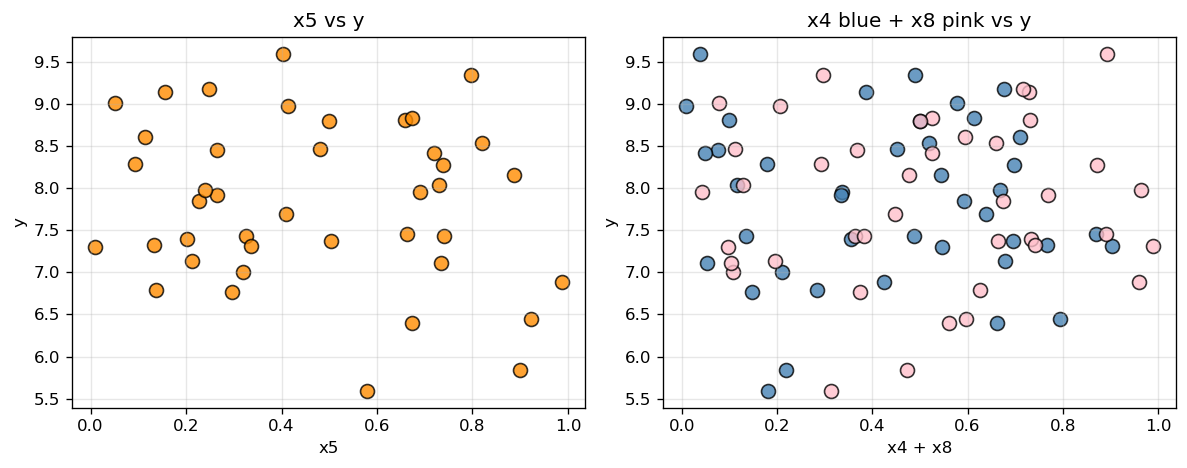

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=120)

axes[0].scatter(df["x5"], y, color="darkorange", edgecolor="k", s=70, alpha=0.8)
axes[0].set_title("x5 vs y")
axes[0].set_xlabel("x5")
axes[0].set_ylabel("y")
axes[0].grid(alpha=0.3)

axes[1].scatter(df["x4"], y, color="steelblue", edgecolor="k", s=70, alpha=0.8)
axes[1].set_title("x4 blue + x8 pink vs y")
axes[1].set_xlabel("x4 + x8")
axes[1].set_ylabel("y")
axes[1].grid(alpha=0.3)

axes[1].scatter(df["x8"], y, color="pink", edgecolor="k", s=70, alpha=0.8)
#axes[1].set_title("x3 vs y")
#axes[1].set_xlabel("x3")
#axes[1].set_ylabel("y")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [40]:
# # use this if you only need to explore specific features
# X = df[["x1", "x2", "x3", "x4"]]
# y = df["y"]

# Automatically detect all input columns (everything except 'y')
Xcols = [col for col in df.columns if col != "y"]
X = df[Xcols]
y = df["y"]

print("Inputs:", list(X.columns), "| X shape:", X.shape, "| y shape:", y.shape)

Inputs: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8'] | X shape: (41, 8) | y shape: (41,)


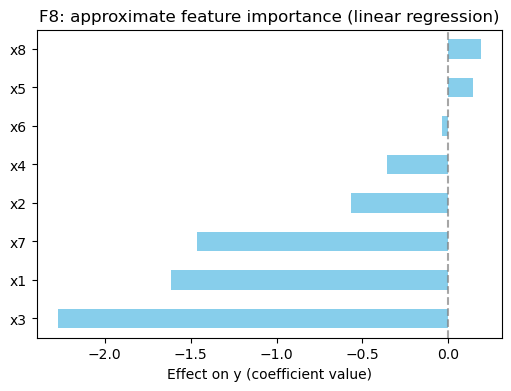

Feature coefficients (sorted):


,Coefficient
x8,0.188110
x5,0.144100
x6,-0.037516
x4,-0.359413
x2,-0.565168
x7,-1.465072
x1,-1.611905
x3,-2.271494


In [41]:
from sklearn.linear_model import LinearRegression

# Fit linear model
model = LinearRegression().fit(X, y)

# Determine column names safely
if hasattr(X, "columns"):
    feature_names = X.columns
else:
    feature_names = [f"x{i+1}" for i in range(X.shape[1])]

# Get coefficients as a Series
importance = pd.Series(model.coef_.ravel(), index=feature_names)

# Visualize
plt.figure(figsize=(6, 4))
importance.sort_values().plot(kind="barh", color="skyblue")
plt.title(f"{FN}: approximate feature importance (linear regression)")
plt.xlabel("Effect on y (coefficient value)")
plt.axvline(0, color="gray", linestyle="--", alpha=0.7)
plt.show()

# Print results neatly
print("Feature coefficients (sorted):")
display(importance.sort_values(ascending=False).to_frame("Coefficient"))


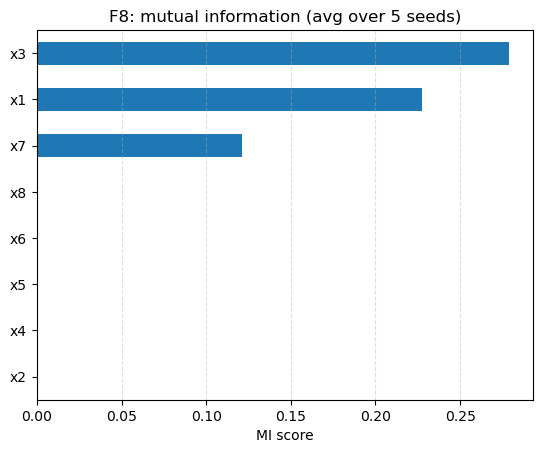

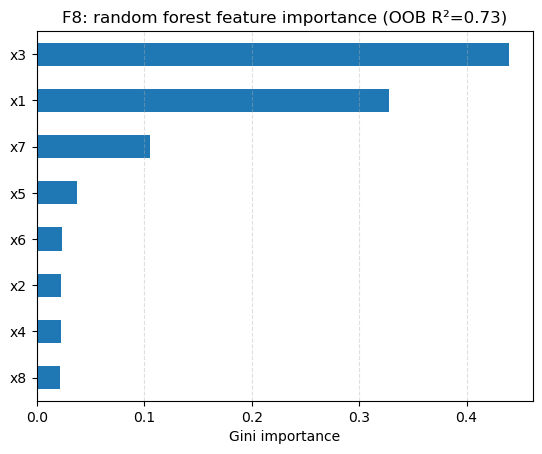

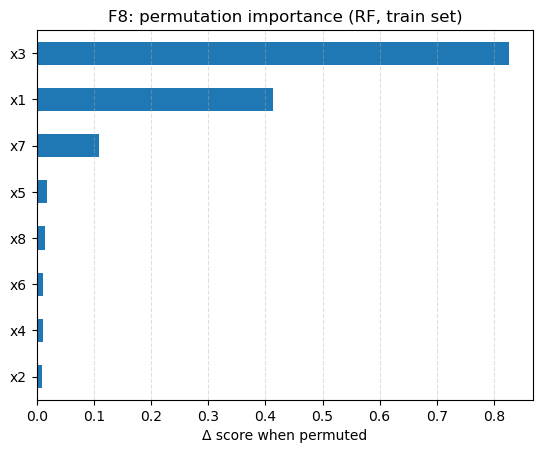

In [42]:
#NON LINEAR IMPORTANCE

from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

# X, y from your DataFrame
X = df[Xcols]
y = df["y"]

# --- 1) Mutual Information (average across seeds to reduce variance) ---
seeds = [0, 1, 2, 3, 4]
mi_runs = []
for s in seeds:
    mi_runs.append(mutual_info_regression(X, y, random_state=s, n_neighbors=3))
mi = np.mean(mi_runs, axis=0)

pd.Series(mi, index=Xcols).sort_values().plot(kind="barh")
plt.title(f"{FN}: mutual information (avg over {len(seeds)} seeds)")
plt.xlabel("MI score")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.show()

# --- 2) Random Forest importance (slight regularization + OOB sanity) ---
rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,   # a touch of regularization for n≈21
    oob_score=True,
    bootstrap=True,
    random_state=0,
)
rf.fit(X, y)
pd.Series(rf.feature_importances_, index=Xcols).sort_values().plot(kind="barh")
plt.title(f"{FN}: random forest feature importance (OOB R²={getattr(rf, 'oob_score_', np.nan):.2f})")
plt.xlabel("Gini importance")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.show()

# --- 3) Permutation importance on the fitted RF (model-agnostic) ---
perm = permutation_importance(rf, X, y, n_repeats=200, random_state=0)
pd.Series(perm.importances_mean, index=Xcols).sort_values().plot(kind="barh")
plt.title(f"{FN}: permutation importance (RF, train set)")
plt.xlabel("Δ score when permuted")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.show()

In [53]:
# --- Robust GP fit (F8) ---
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C, WhiteKernel
import numpy as np, warnings
from sklearn.exceptions import ConvergenceWarning

X_np = np.asarray(X, float)
y_np = np.asarray(y, float).ravel()
d = X_np.shape[1]

# MUCH wider bounds so the optimizer doesn't get "stuck" on the ceiling/floor.
length_bounds = (1e-3, 1e6)          # was (maybe) ~ (1e-3, 1e3)
noise_bounds   = (1e-10, 1e-1)       # allow lower noise than 1e-8

base_kernel = C(1.0, (1e-4, 1e4)) * Matern(length_scale=np.ones(d),
                                           length_scale_bounds=length_bounds,
                                           nu=2.5)
noise_kernel = WhiteKernel(noise_level=1e-6, noise_level_bounds=noise_bounds)

# Alpha adds a tiny diagonal jitter that's separate from the learned noise term.
alpha = 1e-10

def fit_gp(kernel, msg):
    gp_ = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=12,
        random_state=0,
        alpha=alpha,
        optimizer="fmin_l_bfgs_b"
    )
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always", ConvergenceWarning)
        gp_.fit(X_np, y_np)
        hit_bounds = any(isinstance(x.message, ConvergenceWarning) for x in w)
    # Optional: inspect learned kernel
    print(f"[{msg}] kernel after fit:\n  {gp_.kernel_}\n")
    return gp_, hit_bounds

# 1) Fit with learnable noise
gp, hit = fit_gp(base_kernel + noise_kernel, "free-noise")

# 2) If we still hit bounds, refit with fixed (small) noise to stabilize
if hit:
    fixed_noise = 1e-6
    print("Re-fitting with fixed noise (stabilizer) …")
    gp, _ = fit_gp(base_kernel + WhiteKernel(noise_level=fixed_noise,
                                             noise_level_bounds="fixed"),
                   "fixed-noise")



[free-noise] kernel after fit:
  4.2**2 * Matern(length_scale=[2.4, 4.36, 2.24, 3.62, 18.6, 1e+06, 3.16, 1e+06], nu=2.5) + WhiteKernel(noise_level=1e-10)

Re-fitting with fixed noise (stabilizer) …
[fixed-noise] kernel after fit:
  4.2**2 * Matern(length_scale=[2.4, 4.36, 2.24, 3.62, 18.6, 1e+06, 3.16, 3.26e+05], nu=2.5) + WhiteKernel(noise_level=1e-06)



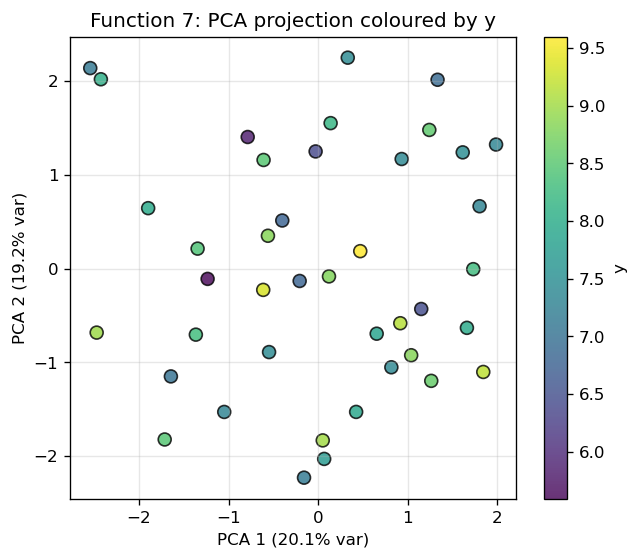

Explained variance ratio: [0.201 0.192]
Total variance explained by first 2 PCs: 39.3%


In [54]:
#PCA PROJECTION FOR INTUITION
#Reduce the 5D into 2 principal components 
#that capture the main variance in your data
#and colour the points by y to spot trends or clusters.

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# --- Standardise inputs (always important before PCA) ---
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# --- Run PCA ---
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_std)

# --- Plot ---
plt.figure(figsize=(6, 5), dpi=120)
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="viridis", s=60, edgecolor="k", alpha=0.8)
plt.xlabel(f"PCA 1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PCA 2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title(f"{FN}: PCA projection coloured by y")
plt.colorbar(sc, label="y")
plt.grid(True, alpha=0.3)
plt.show()

# --- Explained variance info ---
print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 3))
print(f"Total variance explained by first 2 PCs: {pca.explained_variance_ratio_.sum()*100:.1f}%")

In [55]:
# --- Show component loadings (how much each original feature contributes to each PC) ---
loadings = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=["PCA1", "PCA2"]
).T  # transpose so features are rows

display(loadings.style.background_gradient(cmap="coolwarm", axis=None).format("{:+.2f}"))

,PCA1,PCA2
x1,+0.06,+0.52
x2,-0.46,-0.05
x3,+0.02,-0.32
x4,+0.61,-0.04
x5,-0.06,+0.53
x6,-0.03,+0.36
x7,-0.11,+0.45
x8,+0.63,+0.10


Best point (highest y):


,x1,x2,x3,x4,x5,x6,x7,x8,y,dist_from_best
14,0.0564,0.066,0.0229,0.0388,0.4039,0.8011,0.4883,0.8931,9.5985,0.0


Nearest neighbours to best point:


,x1,x2,x3,x4,x5,x6,x7,x8,y,dist_from_best
14,0.0564,0.0660,0.0229,0.0388,0.4039,0.8011,0.4883,0.8931,9.5985,0.0000
22,0.1451,0.1193,0.4209,0.3876,0.1554,0.8752,0.5106,0.7286,9.1416,0.6209
23,0.3390,0.5669,0.3768,0.0989,0.6595,0.2455,0.7625,0.7322,8.8176,0.9667
40,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,8.7983,1.0392
39,0.4812,0.1025,0.2195,0.6773,0.2475,0.2443,0.1638,0.7160,9.1830,1.0484


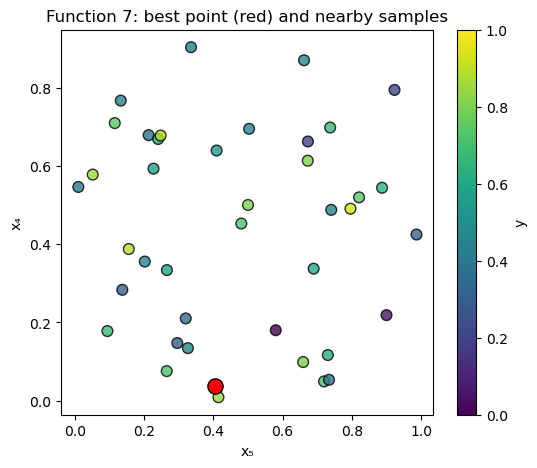

In [56]:
#BEST POINT + NEIGHBORHOOD

# Find best-performing point (highest y)
best_idx = df["y"].idxmax()
best_row = df.loc[best_idx]
print("Best point (highest y):")
display(best_row.to_frame().T.round(4))

# Recompute clean X columns (exclude helper columns if already exist)
Xcols = [c for c in df.columns if c not in ["y", "dist_from_best"]]

# Compute Euclidean distance from each point to the best point
df["dist_from_best"] = ((df[Xcols] - best_row[Xcols])**2).sum(axis=1)**0.5

# Show the closest 5 points (including the best one)
neighbors = df.nsmallest(5, "dist_from_best")
print("Nearest neighbours to best point:")
display(neighbors[Xcols + ["y", "dist_from_best"]].round(4))

# Optional: simple visual check (2D projection using x4 and x5)
plt.figure(figsize=(6,5))
plt.scatter(df["x5"], df["x4"], c=df["y"], cmap="viridis", s=60, edgecolor="k", alpha=0.8)
plt.scatter(best_row["x5"], best_row["x4"], c="red", s=120, edgecolor="k", label="Best point")
plt.xlabel("x₅"); plt.ylabel("x₄")
plt.title(f"{FN}: best point (red) and nearby samples")
plt.colorbar(label="y")
#plt.legend()
plt.show()


Surrogate RF fitted. CV R^2 ≈ 0.57 | OOB R^2 ≈ 0.60


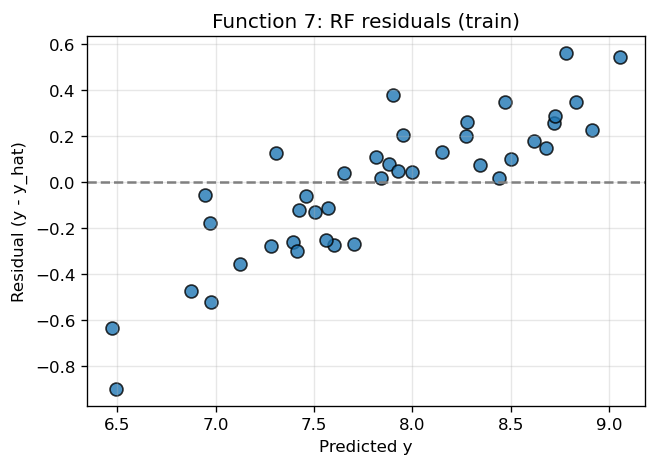

In [57]:
# FIT A SURROGATE
from sklearn.model_selection import KFold, cross_val_score

# --- robust, low-tuning surrogate ---
rf = RandomForestRegressor(
    n_estimators=600,
    max_depth=None,
    max_features="sqrt",   # robust default
    min_samples_leaf=2,    # gentle regularization for n≈21
    bootstrap=True,
    oob_score=True,        # extra generalization check
    random_state=0,
    n_jobs=-1,
)
rf.fit(X, y)

# ---- CV (shuffle for stability on tiny datasets) ----
cv = min(5, len(df))
kf = KFold(n_splits=cv, shuffle=True, random_state=0)
cv_r2 = cross_val_score(rf, X, y, cv=kf, scoring="r2").mean()

print(f"Surrogate RF fitted. CV R^2 ≈ {cv_r2:.2f} | OOB R^2 ≈ {getattr(rf, 'oob_score_', np.nan):.2f}")

# ---- quick residual check ----
y_hat = rf.predict(X)
resid = y - y_hat
plt.figure(figsize=(6,4), dpi=120)
plt.scatter(y_hat, resid, s=60, edgecolor="k", alpha=0.8)
plt.axhline(0, color="gray", ls="--")
plt.xlabel("Predicted y")
plt.ylabel("Residual (y - y_hat)")
plt.title(f"{FN}: RF residuals (train)")
plt.grid(alpha=0.3)
plt.show()

In [58]:
# CANDIDATE GENERATION
# === CANDIDATE GENERATION (global + local) and SCORING (RF + EI) ===
import numpy as np
from scipy.stats import norm

# 0) Domain bounds — prefer portal bounds (do NOT fall back to observed)
d = len(Xcols)
portal_bounds = np.array([[0.0, 1.0]] * d)  # <-- replace if your portal bounds differ
lo, hi = portal_bounds[:,0].copy(), portal_bounds[:,1].copy()

# (Optional: KEEP THESE ONLY FOR REPORTING, NOT FOR SCALING)
# obs_lo = df[Xcols].min().to_numpy(float)
# obs_hi = df[Xcols].max().to_numpy(float)
# NOTE: Do not overwrite lo/hi with observed min/max for candidate scaling.

# Fallback to observed if any bound is degenerate (shouldn't happen here)
obs_lo = df[Xcols].min().to_numpy(float)
obs_hi = df[Xcols].max().to_numpy(float)
deg = (hi - lo) < 1e-12
lo = np.where(deg, obs_lo, lo)
hi = np.where(deg, obs_hi, hi)

def sample_lhs(n, d, rng):
    cut = np.linspace(0, 1, n+1)
    u = rng.uniform(size=(n, d))
    a, b = cut[:-1][:,None], cut[1:][:,None]
    X = a + (b-a)*u
    for j in range(d):
        rng.shuffle(X[:, j])
    return X

rng = np.random.default_rng(42)
N_GLOBAL = 6000
N_LOCAL  = 4000
trust_region_frac = 0.15   # 15% of range in unit space

# 1) Global candidates in [0,1]^d via LHS
C_global_u = sample_lhs(N_GLOBAL, d, rng)

# 2) Local candidates around the incumbent (in unit space)
best_idx = df["y"].idxmax()
x_best   = df.loc[best_idx, Xcols].to_numpy(float)
x_best_u = (x_best - lo) / (hi - lo + 1e-12)
C_local_u = np.clip(
    x_best_u + rng.normal(scale=trust_region_frac, size=(N_LOCAL, d)),
    0, 1
)

# Merge and scale back to original domain
C_u = np.vstack([C_global_u, C_local_u])
C   = lo + C_u * (hi - lo)

# --- Sanity check: candidate coverage ---
print("cand shape:", C.shape)
print("feature columns:", Xcols)

mins = C.min(axis=0)
maxs = C.max(axis=0)
for c, lo_i, hi_i, mn, mx in zip(Xcols, lo, hi, mins, maxs):
    print(f"{c}: bounds [{lo_i:.3f}, {hi_i:.3f}]  |  cand range [{mn:.3f}, {mx:.3f}]")

# 3) Score candidates with RF mean + uncertainty from trees
#    (tree-wise predictions -> mean & std)
tree_preds = np.stack([est.predict(C) for est in rf.estimators_], axis=0)  # (n_trees, n_cand)
mu  = tree_preds.mean(axis=0)
sd  = tree_preds.std(axis=0, ddof=1)

# 4) Acquisition: Expected Improvement (maximize)
y_best = df["y"].max()
xi = 0.02  # exploration knob
sd_safe = np.maximum(sd, 1e-12)
imp = mu - y_best - xi
Z = imp / sd_safe
EI = imp * norm.cdf(Z) + sd_safe * norm.pdf(Z)

# 5) (Optional) minimum distance filter so we don't resample too close to existing points
Xu = (df[Xcols].to_numpy(float) - lo) / (hi - lo + 1e-12)
min_dist = 0.02
def too_close(z, Z, thr=min_dist):
    diff = Z - z
    return np.any(np.sqrt((diff*diff).sum(axis=1)) < thr)

order = np.argsort(-EI)
pick_u = None

# --- Prevent exact duplicates + near duplicates ---
# Create a set of tuples representing existing points rounded to 6 decimals
existing = set(tuple(np.round(x, 6)) for x in Xu)

for idx in order:
    cand_u = C_u[idx]
    tup = tuple(np.round(cand_u, 6))
    # Skip if identical to an existing point OR too close in space
    if tup not in existing and not too_close(cand_u, Xu, thr=min_dist):
        pick_u = cand_u
        pick_idx = idx
        break

# Fallback if all candidates are too close
if pick_u is None:
    pick_u = C_u[order[0]]
    pick_idx = order[0]

x_next = lo + pick_u * (hi - lo)

print(f"{FN} — candidate selection")
print(f"Best y so far: {y_best:.6f}")
print(f"Chosen by EI (xi={xi}): predicted mean={mu[pick_idx]:.4f}, std={sd[pick_idx]:.4f}, EI={EI[pick_idx]:.4f}")
print("x_next:", np.round(x_next, 6))

cand shape: (10000, 8)
feature columns: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8']
x1: bounds [0.000, 1.000]  |  cand range [0.000, 1.000]
x2: bounds [0.000, 1.000]  |  cand range [0.000, 1.000]
x3: bounds [0.000, 1.000]  |  cand range [0.000, 1.000]
x4: bounds [0.000, 1.000]  |  cand range [0.000, 1.000]
x5: bounds [0.000, 1.000]  |  cand range [0.000, 1.000]
x6: bounds [0.000, 1.000]  |  cand range [0.000, 1.000]
x7: bounds [0.000, 1.000]  |  cand range [0.000, 1.000]
x8: bounds [0.000, 1.000]  |  cand range [0.000, 1.000]
Function 7 — candidate selection
Best y so far: 9.598482
Chosen by EI (xi=0.02): predicted mean=8.5521, std=0.9358, EI=0.0593
x_next: [0.254309 0.083602 0.28726  0.359276 0.933263 0.99645  0.018674 0.732495]


In [59]:
# --- Candidate pool (Sobol global + local around top-3) ---
import numpy as np
from scipy.stats import qmc

# Ensure NumPy arrays
X_np = np.asarray(X, dtype=float)
y_np = np.asarray(y, dtype=float).ravel()

d = X_np.shape[1]
rng = np.random.default_rng(1)

# Portal bounds in [0,1]
portal_bounds = np.array([[0.0, 1.0]] * d)
lo, hi = portal_bounds[:, 0], portal_bounds[:, 1]

# Global Sobol
sampler = qmc.Sobol(d=d, scramble=True, seed=1)
C_global = sampler.random_base2(m=12)  # 4096 candidates in [0,1]^d

# Local neighborhoods around current top-3 (by y)
best_idx = np.argsort(-y_np)[:3]
centers = X_np[best_idx]                 # <-- works because it's NumPy
locals_ = []
for center in centers:
    noise = rng.normal(scale=0.05, size=(400, d))
    loc = np.clip(center + noise, 0, 1)
    locals_.append(loc)

C_local = np.vstack(locals_)
C = np.vstack([C_global, C_local])


In [60]:
from scipy.stats import norm

mu, sd = gp.predict(C, return_std=True)
y_best = float(np.max(y))
xi = 0.01

imp = mu - y_best - xi
Z = np.divide(imp, sd, out=np.zeros_like(imp), where=sd > 0)
EI = imp * norm.cdf(Z) + sd * norm.pdf(Z)

# === Select next candidate using diversity constraint ===
order = np.argsort(-EI)

def min_dist(u, Xarr):
    u = np.asarray(u, dtype=float)
    Xarr = np.asarray(Xarr, dtype=float)
    return float(np.sqrt(((Xarr - u)**2).sum(axis=1)).min())

thr = 0.05  # minimum distance threshold
pick_idx = None
for idx in order:
    if min_dist(C[idx], X_np) >= thr:
        pick_idx = idx
        break
if pick_idx is None:
    pick_idx = order[0]  # fallback if all are too close

# Chosen candidate
x_next = C[pick_idx]


print("F7 — Next query (EI):", np.round(x_next, 6))



F7 — Next query (EI): [0.231868 0.356115 0.159692 0.196372 0.938094 0.792984 0.113027 0.830933]


In [62]:
# --- Quiet down GP optimizer warnings (optional, cosmetic) ---
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# ===========================
# F8 — FINAL OUTPUT BLOCK (robust)
# ===========================
import numpy as np, pandas as pd
from IPython.display import display
from scipy.stats import norm

FN = "F8"

# Sanity: make sure arrays are right-shaped
X_np = np.asarray(X, float)
y_np = np.asarray(y, float).ravel()
assert X_np.ndim == 2 and y_np.ndim == 1 and X_np.shape[0] == y_np.shape[0], "X/y shapes mismatch"

d = X_np.shape[1]
Xcols = [f"x{i+1}" for i in range(d)]

# Portal domain only
portal_bounds = np.array([[0.0, 1.0]] * d, float)

# ---- Candidate set (global Sobol + local jitter around top-3) ----
from scipy.stats import qmc
rng = np.random.default_rng(42)
sampler = qmc.Sobol(d=d, scramble=True, seed=1)
C_global = sampler.random_base2(m=12)  # 4096 candidates in [0,1]^d

topk = min(3, len(y_np))
centers = X_np[np.argsort(-y_np)[:topk]]
locals_ = []
for c in centers:
    noise = rng.normal(scale=0.05, size=(2000, d))
    locals_.append(np.clip(c + noise, portal_bounds[:,0], portal_bounds[:,1]))
C_local = np.vstack(locals_) if locals_ else np.empty((0, d))
C = np.vstack([C_global, C_local])

# ---- Predict on candidates ----
mu, sd = gp.predict(C, return_std=True)
y_best = float(np.max(y_np))

# ---- EI with rock-solid numerics ----
xi = 0.01
imp = mu - y_best - xi
with np.errstate(divide='ignore', invalid='ignore'):
    Z = np.zeros_like(imp)
    pos = sd > 0
    Z[pos] = imp[pos] / sd[pos]
EI = np.zeros_like(imp)
# Use stable formula; where sd==0, EI stays 0
EI[pos] = imp[pos] * norm.cdf(Z[pos]) + sd[pos] * norm.pdf(Z[pos])

# ---- Diversity guard with graceful fallback ----
def min_dist(u, Xarr):
    # works even if Xarr has one row
    diffs = Xarr - u
    return float(np.sqrt(np.sum(diffs * diffs, axis=1)).min())

thr = 0.05
order = np.argsort(-EI)
pick_idx = None
for idx in order:
    if min_dist(C[idx], X_np) >= thr:
        pick_idx = idx
        break
if pick_idx is None:
    # If everything is too close, relax threshold progressively
    for t in (0.025, 0.01, 0.0):
        for idx in order:
            if min_dist(C[idx], X_np) >= t:
                pick_idx = idx
                break
        if pick_idx is not None:
            break
    if pick_idx is None:
        pick_idx = order[0]  # absolute fallback

x_next = C[pick_idx]

# ---- Pretty print + table ----
print("\n" + "="*70)
print(f"{FN} — RECOMMENDED NEXT POINT")
print("="*70)
print(f"Best y so far: {y_best:.6f}")
print(f"Chosen by EI (xi={xi}): predicted mean={mu[pick_idx]:.6f}, "
      f"std={sd[pick_idx]:.6f}, EI={EI[pick_idx]:.6f}")
print(f"Min distance from existing points: {min_dist(x_next, X_np):.6f}")

x_next_df = pd.DataFrame([x_next], columns=Xcols).round(6)
try:
    display(x_next_df.style.set_caption('🚀 Recommended query to submit this week'))
except Exception:
    # Some environments lack Styler; fall back to plain display
    display(x_next_df)

# ---- Persist selection for your weekly log ----
from datetime import datetime
stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
outpath = f"{FN}_xnext_{stamp}.csv"
x_next_df.to_csv(outpath, index=False)
print(f"\nSaved selection to {outpath}")



F8 — RECOMMENDED NEXT POINT
Best y so far: 9.598482
Chosen by EI (xi=0.01): predicted mean=9.971801, std=0.132867, EI=0.363445
Min distance from existing points: 0.763013


,x1,x2,x3,x4,x5,x6,x7,x8
0,0.231868,0.356115,0.159692,0.196372,0.938094,0.792984,0.113027,0.830933



Saved selection to F8_xnext_20251022_050656.csv


In [52]:
# === FINAL OUTPUT: RECOMMENDED NEXT POINT TO SUBMIT ===
import numpy as np
import pandas as pd
from IPython.display import display

FN = "Function 7"

# Safety: ensure NumPy arrays
X_np = np.asarray(X, dtype=float)
x_next = np.asarray(x_next, dtype=float)

# Helper: min distance to existing points
def min_dist(u, Xarr):
    u = np.asarray(u, dtype=float)
    Xarr = np.asarray(Xarr, dtype=float)
    return float(np.sqrt(((Xarr - u)**2).sum(axis=1)).min())

print("\n" + "="*70)
print(f"{FN} — RECOMMENDED NEXT POINT")
print("="*70)

print(f"Best y so far: {y_best:.6f}")
print(f"Chosen by EI (xi={xi}): predicted mean={mu[pick_idx]:.4f}, "
      f"std={sd[pick_idx]:.4f}, EI={EI[pick_idx]:.4f}")
print(f"Min distance from existing points: {min_dist(x_next, X_np):.3f}")

# Pretty output table
Xcols = list(X.columns) if hasattr(X, "columns") else [f"x{i+1}" for i in range(x_next.size)]
x_next_df = pd.DataFrame([x_next], columns=Xcols).round(6)
display(x_next_df.style.set_caption("🚀 Recommended query to submit this week"))

print("="*70)
print("Copy these values into the Capstone submission portal for this week's query.")
print("="*70)



Function 7 — RECOMMENDED NEXT POINT
Best y so far: 9.598482
Chosen by EI (xi=0.01): predicted mean=9.9718, std=0.1329, EI=0.3634
Min distance from existing points: 0.763


,x1,x2,x3,x4,x5,x6,x7,x8
0,0.231868,0.356115,0.159692,0.196372,0.938094,0.792984,0.113027,0.830933


Copy these values into the Capstone submission portal for this week's query.


IF YOU WANT TO AUTOMATE KEEPING THE RESULT IN A FILE

# --- Persist the chosen point for weekly tracking ---
log_row = pd.DataFrame([x_next], columns=Xcols).round(6)
log_row["y_best_so_far"] = float(y_best)
log_row["pred_mean"]     = float(mu[pick_idx])
log_row["pred_std"]      = float(sd[pick_idx])
log_row["EI"]            = float(EI[pick_idx])
log_row["timestamp"]     = pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")

save_path = DATA / FN / "proposed_next.csv"

# Append if file exists, else create
if save_path.exists():
    prev = pd.read_csv(save_path)
    out  = pd.concat([prev, log_row], ignore_index=True)
else:
    out = log_row

out.to_csv(save_path, index=False)
print("✅ Saved proposal log to:", save_path)
display(out.tail(3))  # show the last few entries


In [ ]:
#import numpy as np, pandas as pd
#np.save("F7_next_query.npy", x_next)
#pd.DataFrame([x_next], columns=[f"x{i+1}" for i in range(6)]).to_csv("F7_next_query.csv", index=False)
